# 평균, 표준편차 : P. 215

자동차 연비 Data Set에서 기술통계치 구하기  

▪시내에서연비(mpg) 통계치구하기: 데이터수, 평균, 중앙값,표준편차, min, max, Q1, Q3   
▪자동차모델별, mpg 기술통계치구하기: 데이터수, 평균, 중앙값,표준편차, min, max, Q1, Q3   
 ( data.set: mycars.csv )  

In [4]:
# 패키지 불러오기 (기본)

# 데이터 구성 패키지 : Series, DataFrame
import pandas as pd

# 행렬 연산 패키지
import numpy as np

# 데이터 시각화 패키지
import matplotlib
import matplotlib.pyplot as plt

# 통계 분석 패키지
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# 그래프 표시
%matplotlib inline


In [5]:
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mycars.csv")
mycars.head()


,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [ ]:
# 요약 기초 통계량 (count, mean(평균), std(표준편차), min, 25, 50, 75, max)
mycars.describe().round(3)

# round(n) : n번째까지 반올림



,displacement,year,cylinder,mpg,highway_mileage
count,234.000,234.00,234.000,234.000,234.000
mean,3.472,2003.50,5.889,16.859,23.440
std,1.292,4.51,1.612,4.256,5.955
min,1.600,1999.00,4.000,9.000,12.000
25%,2.400,1999.00,4.000,14.000,18.000
50%,3.300,2003.50,6.000,17.000,24.000
75%,4.600,2008.00,8.000,19.000,27.000
max,7.000,2008.00,8.000,35.000,44.000


In [23]:
# 자동차 모델별, mpg 데이터 subset(데이터셋에서 필요한 부분만 골라낸 부분 집합)
# Subset: df (model과 mpg 열만 추출하여 새로 만든 데이터프레임)
df = mycars[['model', 'mpg']]
df.groupby('model').describe().head()

mpg                                                     
            count       mean       std   min    25%   50%    75%   max
model                                                                 
4runner 4wd   6.0  15.166667  0.752773  14.0  15.00  15.0  15.75  16.0
a4            7.0  18.857143  1.864454  16.0  18.00  18.0  20.50  21.0
a4 quattro    8.0  17.125000  1.807722  15.0  15.75  17.0  18.25  20.0
a6 quattro    3.0  16.000000  1.000000  15.0  15.50  16.0  16.50  17.0
altima        6.0  20.666667  1.966384  19.0  19.00  20.0  22.50  23.0

추가------------------------------------------------------------------------------------------------------

In [ ]:
# 이렇게 할 수도 있다.
# mean(평균), std(표준편차) 만데리고 오겠다.
# mycars.describe().loc[['mean', 'std']].round(3) : 이건 해당 열이름이 존재할때만 사용가능
stats = mycars.agg(['mean', 'std']).round(3)
stats

C:\Users\User\AppData\Local\Temp\ipykernel_1624\4101544710.py:3: FutureWarning: ['manufacturer', 'model', 'automatic', 'driving', 'fuel', 'class'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  stats = mycars.agg(['mean', 'std']).round(3)


,displacement,year,cylinder,mpg,highway_mileage
mean,3.472,2003.50,5.889,16.859,23.440
std,1.292,4.51,1.612,4.256,5.955


In [17]:
# 자동차 모델별, mpg 데이터 subset(데이터셋에서 필요한 부분만 골라낸 부분 집합)
# Subset: df (model과 mpg 열만 추출하여 새로 만든 데이터프레임)
df = mycars[['model', 'mpg']]
df.head()

,model,mpg
0,a4,18
1,a4,21
2,a4,20
3,a4,21
4,a4,16


In [25]:
# 이건 아닌 것 같아
df.groupby('model')['mpg'].agg(['mean', 'std']).head()

,mean,std
model,,
4runner 4wd,15.166667,0.752773
a4,18.857143,1.864454
a4 quattro,17.125000,1.807722
a6 quattro,16.000000,1.000000
altima,20.666667,1.966384


# P.217 저 풉니다~

자동차연비Data Set에서기술통계치구하기  
-시내에서연비(mpg) 통계치: 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3  
-> 이거 시내로 묶고 mpg 해야하는거 아닌가?  아 그냥 이거 자체가 시내 인가봐   (기초통계량)  
-> 구동방식!!! 별로 묶어야하는 거였음 ㅠ  
-고속도로에서연비(mpg) 통계치 : 구동방식별 데이터수, 평균, 중앙값, 표준편차, min, max, Q1, Q3  
-> 이거 고속도로로 묶고 mpg 아닌가...  
( data.set : mycars.csv )

In [26]:
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mycars.csv")
mycars.head()


,manufacturer,model,displacement,year,cylinder,automatic,driving,mpg,highway_mileage,fuel,class
0,audi,a4,1.8,1999,4,auto,f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual,f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual,f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto,f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto,f,16,26,p,compact


In [ ]:
df = mycars[['driving', 'mpg']]
df.groupby('driving').describe().round(3).head()

mpg                                             
         count    mean    std   min   25%   50%   75%   max
driving                                                    
4        103.0  14.330  2.874   9.0  13.0  14.0  16.0  21.0
f        106.0  19.972  3.627  11.0  18.0  19.0  21.0  35.0
r         25.0  14.080  2.216  11.0  12.0  15.0  15.0  18.0

In [ ]:
df = mycars[['driving', 'highway_mileage']]
df.groupby('driving').describe().head()

highway_mileage                                                   
                  count       mean       std   min   25%   50%   75%   max
driving                                                                   
4                 103.0  19.174757  4.078704  12.0  17.0  18.0  22.0  28.0
f                 106.0  28.160377  4.206881  17.0  26.0  28.0  29.0  44.0
r                  25.0  21.000000  3.662877  15.0  17.0  21.0  24.0  26.0

# 그냥 궁금해서 한 번 열어보려고 

📝 [연습 문제] 자동차 데이터 기술통계 분석 (손코딩)
데이터셋 정보: mpg.csv (변수명: mycars)

문제:
다음 요구사항에 맞게 각 단계의 파이썬(Pandas) 코드를 작성하시오. (단, 모든 결과값은 소수점 셋째 자리까지 반올림하여 표시하시오.)

시내 연비 분석: '구동방식(drive-wheels)별'로 '시내 연비(city-mpg)의 통계치'를 구하시오.

(출력 항목: 데이터 수, 평균, 중앙값, 표준편차, 최솟값, 최댓값, 1사분위수, 3사분위수)

고속도로 연비 분석: '구동방식(drive-wheels)별'로 '고속도로 연비(highway-mpg)의 통계치'를 구하시오.

(출력 항목: 데이터 수, 평균, 중앙값, 표준편차, 최솟값, 최댓값, 1사분위수, 3사분위수)

In [35]:
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mpg.csv")
mycars.head()

,make,fuel-type,drive-wheels,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,audi,gas,fwd,176.6,66.2,54.3,2337,ohc,four,109,3.19,3.4,102,5500,24,30,13950
1,audi,gas,4wd,176.6,66.4,54.3,2824,ohc,five,136,3.19,3.4,115,5500,18,22,17450
2,audi,gas,fwd,177.3,66.3,53.1,2507,ohc,five,136,3.19,3.4,110,5500,19,25,15250
3,audi,gas,fwd,192.7,71.4,55.7,2844,ohc,five,136,3.19,3.4,110,5500,19,25,17710
4,audi,gas,fwd,192.7,71.4,55.7,2954,ohc,five,136,3.19,3.4,110,5500,19,25,18920


In [36]:
df = mycars[['drive-wheels', 'city-mpg']]
df.groupby('drive-wheels').describe().round(3).head()

city-mpg                                              
                count    mean    std   min    25%   50%   75%   max
drive-wheels                                                       
4wd               4.0  22.000  5.831  16.0  17.50  22.5  27.0  27.0
fwd              22.0  27.955  5.908  17.0  24.75  28.5  31.0  38.0
rwd              60.0  20.750  4.120  13.0  17.00  20.0  24.0  29.0

In [37]:
df = mycars[['drive-wheels', 'highway-mpg']]
df.groupby('drive-wheels').describe().round(3).head()

highway-mpg                                               
                   count    mean    std   min    25%   50%    75%   max
drive-wheels                                                           
4wd                  4.0  27.000  5.774  22.0  22.00  27.0  32.00  32.0
fwd                 22.0  33.773  6.553  20.0  31.25  34.0  37.00  47.0
rwd                 60.0  25.583  4.315  16.0  24.00  25.0  28.25  34.0

# 하나 더

📝 [심화 문제] 특정 조건 필터링 및 기술통계 구하기
데이터셋 정보: mpg.csv (변수명: mycars)

문제:
자동차 연료 타입(fuel-type)이 'gas'인 자동차들만 추출하여, '제조사(make)별'로 '가격(price)의 통계치'를 구하시오.

필터링: fuel-type이 gas인 데이터만 추출하여 새로운 변수(gas_cars)에 저장하시오.

분석: gas_cars를 사용하여 제조사(make)별 가격(price)의 기술통계치(describe)를 구하시오.

마무리: 결과값은 소수점 첫째 자리까지 반올림하시오.

In [38]:
mycars = pd.read_csv(r"D:\BigData_수업용\2605619_33기 AI·Big Data 실습 파일, 연습 코드\1. Big Data 분석 기초 실습파일\mpg.csv")
mycars.head()

,make,fuel-type,drive-wheels,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,bore,stroke,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,audi,gas,fwd,176.6,66.2,54.3,2337,ohc,four,109,3.19,3.4,102,5500,24,30,13950
1,audi,gas,4wd,176.6,66.4,54.3,2824,ohc,five,136,3.19,3.4,115,5500,18,22,17450
2,audi,gas,fwd,177.3,66.3,53.1,2507,ohc,five,136,3.19,3.4,110,5500,19,25,15250
3,audi,gas,fwd,192.7,71.4,55.7,2844,ohc,five,136,3.19,3.4,110,5500,19,25,17710
4,audi,gas,fwd,192.7,71.4,55.7,2954,ohc,five,136,3.19,3.4,110,5500,19,25,18920


In [43]:
# 1. 필터링: 연료 타입이 'gas'인 데이터만 추출하여 gas_cars에 저장
# gas_cars = mycars[...]: 전체 데이터(mycars)에서 가솔린 차만 골라내서 gas_cars라는 새 주머니를 만들었습니다.
gas_cars = mycars[mycars['fuel-type'] == 'gas']

# 2. Subset 만들기: 제조사(make)와 가격(price)만 추출  
# df = gas_cars[['make', 'price']]: 방금 만든 gas_cars 주머니에서 다시 제조사와 가격 열만 뽑아내서 df라는 최종 주머니를 만들었습니다.    
df = gas_cars[['make', 'price']]

#df.groupby(...): 그 최종 주머니(df)를 가지고 통계를 낸 것이죠.
df.groupby('make').describe().round(3).head()

price                   
              count unique    top freq
make                                  
audi              7      7  13950    1
bmw               8      8  16430    1
jaguar            3      3  32250    1
mercedes-benz     4      4  34184    1
peugot            6      6  11900    1

# 문제 하나만 더

📝 [손코딩 연습 문제 - 중간 난이도]
데이터셋: mycars (mpg.csv 파일)

문제:
차량의 마력(horsepower)이 110 이상인 고성능 차량들을 대상으로, 연료 타입(fuel-type)별 가격(price)의 기술통계치를 구하시오.

필터링: horsepower가 110 이상인 데이터만 추출하여 powerful_cars 변수에 저장하시오.

분석: powerful_cars를 사용하여 fuel-type별 price의 기술통계치(describe)를 구하시오.

마무리: 모든 결과값은 소수점 둘째 자리까지 반올림(round)하여 표시하시오.

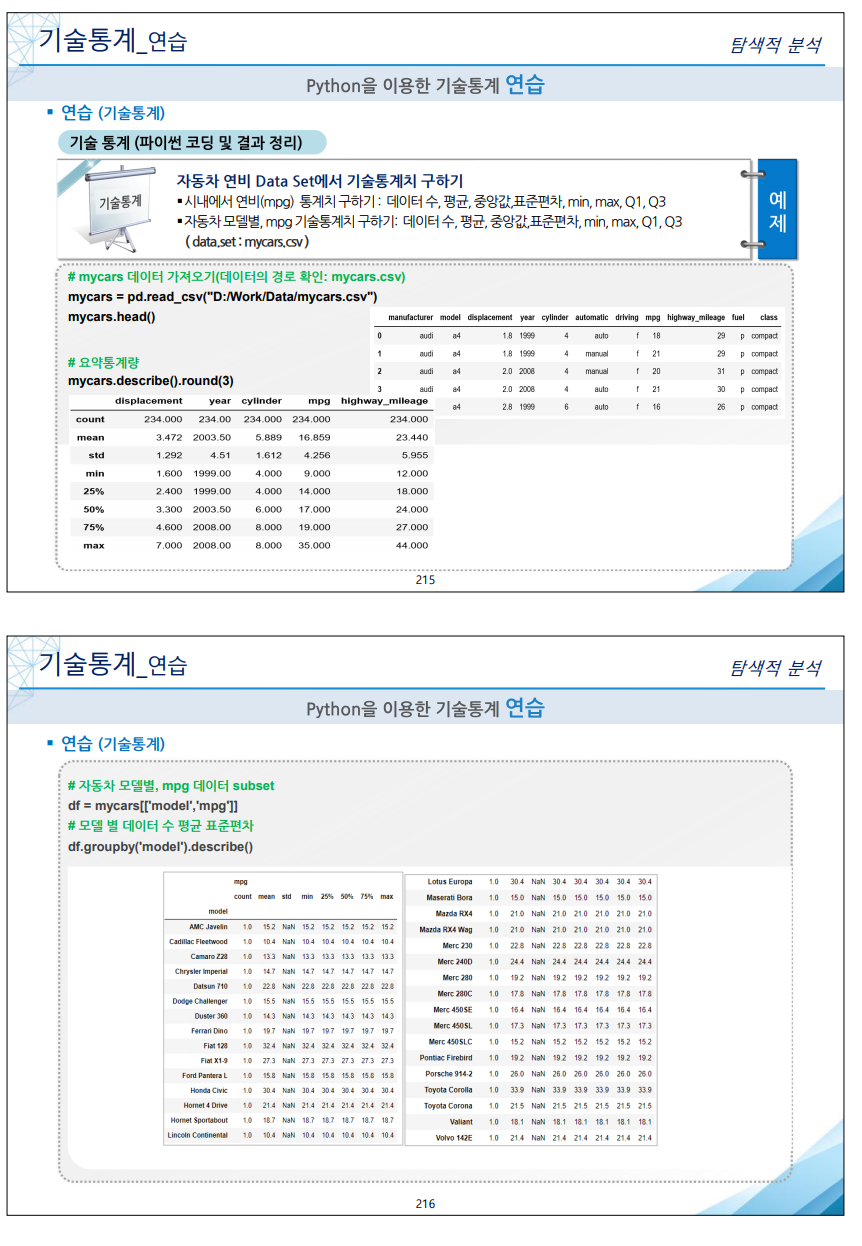